In [4]:
# ============================================
# YZR502u10a01: Robotik NLP Uçtan Uca Boru Hattı
# ============================================
!pip install gtts
!pip install -q git+https://github.com/openai/whisper.git
!pip install -q soundfile numpy pybullet transformers torch
!apt-get install -q libsndfile1

import whisper
import soundfile as sf
import numpy as np
import time
import re
from transformers import pipeline
import pybullet as p
import pybullet_data
import time as pyb_time
import matplotlib.pyplot as plt

print("Tüm kütüphaneler yüklendi.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.3
    Uninstalling click-8.3.3:
      Successfully uninstalled click-8.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are in

In [3]:
import os
import soundfile as sf
from google.colab import files
import IPython.display as ipd

print("Lütfen ses dosyanızı yükleyin:")
uploaded = files.upload()
fn = list(uploaded.keys())[0]
dosya_adi, uzanti = os.path.splitext(fn)
ses_dosyasi = fn

print(f"\n⏳ İşleniyor: {fn}...")

# 1. Dosya WAV değilse dönüştür
if uzanti.lower() != '.wav':
    ses_dosyasi = f"{dosya_adi}_donusturulmus.wav"
    komut = f'ffmpeg -hide_banner -loglevel error -y -i "{fn}" "{ses_dosyasi}"'
    os.system(komut)

# 2. Dönüştürülen (veya zaten WAV olan) dosyayı oku
audio, fs = sf.read(ses_dosyasi)

# Çift kanallıysa (Stereo) tek kanala (Mono) düşür
if len(audio.shape) > 1:
    audio = audio[:, 0]  # mono

# Çıktıda orijinal adı (fn) değil, dönüştürülen WAV dosyasının adını (islem_dosyasi) yazdırıyoruz
print(f"Yüklendi: {ses_dosyasi}, Süre: {len(audio)/fs:.2f}s, Frekans: {fs} Hz")

audio = audio.astype(np.float32)
if np.abs(audio).max() > 0:
    audio = audio / np.abs(audio).max()

display(ipd.Audio(ses_dosyasi))

Lütfen ses dosyanızı yükleyin:


Saving ses1.m4a to ses1 (1).m4a

⏳ İşleniyor: ses1 (1).m4a...
Yüklendi: ses1 (1)_donusturulmus.wav, Süre: 5.18s, Frekans: 44100 Hz


NameError: name 'np' is not defined

In [3]:
# TODO: Whisper modelini yükleyin ve transkripsiyon yapın.
# Model seçin: "tiny", "base" veya "small"
# Sonuçları asr_text ve asr_confidence değişkenlerine atayın.

import math

asr_sonuclari = {}
modeller =  [ "base", "small","tiny"]

for MODEL_ADI in modeller:

    print(f"[1/6] ASR - Model '{MODEL_ADI}' yükleniyor...")
    t0 = time.time()

    # TODO: whisper.load_model(...) ile modeli yükle
    model = whisper.load_model(MODEL_ADI)

    # TODO: model.transcribe(...) ile metni çıkar
    result = model.transcribe(ses_dosyasi, language="tr")

    asr_text = result["text"].strip()
    asr_confidence = 0.0  # TODO: güven skoru hesapla (örn. ortalama log prob)

    if len(result["segments"]) > 0:

        toplam_logprob = sum(segment["avg_logprob"] for segment in result["segments"])
        ortalama_logprob = toplam_logprob / len(result["segments"])

        asr_confidence = math.exp(ortalama_logprob)
    else:
        asr_confidence = 0.0

    t1 = time.time()
    asr_time = t1 - t0

    asr_sonuclari[MODEL_ADI] = {
        "text": asr_text,
        "confidence": asr_confidence,
        "sure": asr_time
    }

    print(f"ASR Çıktısı: \"{asr_text}\"")
    print(f"ASR Süresi: {asr_time:.2f}s")
    print(f"ASR Güven Skoru: {asr_confidence:.2f}")
    print("\n")

asr_text = asr_sonuclari["tiny"]["text"]
asr_confidence = asr_sonuclari["tiny"]["confidence"]
asr_time = asr_sonuclari["tiny"]["sure"]
MODEL_ADI = "tiny"

[1/6] ASR - Model 'base' yükleniyor...


100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 74.6MiB/s]


ASR Çıktısı: "Kırmızı kutuyu be rafından al ve palete bırak."
ASR Süresi: 6.92s
ASR Güven Skoru: 0.67


[1/6] ASR - Model 'small' yükleniyor...


100%|████████████████████████████████████████| 461M/461M [00:02<00:00, 239MiB/s]


ASR Çıktısı: "Kırmızı kutuyu B rıfından al ve palete bırak."
ASR Süresi: 7.11s
ASR Güven Skoru: 0.80


[1/6] ASR - Model 'tiny' yükleniyor...


100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 104MiB/s]


ASR Çıktısı: "Karımıza kötü yübe, rıfından al ve palete bırak."
ASR Süresi: 2.04s
ASR Güven Skoru: 0.52




In [2]:
# TODO: Kural tabanlı
# Niyet sınıfları: nesne_tasima, robot_hareket, bilgi_sorgulama, acil_durdurma
# Varlık tipleri: renk, nesne, kaynak, hedef, yon, hiz

print("[2/6] NLU - Niyet ve varlık çıkarılıyor...")
t0 = time.time()

# TODO: Aşağıdaki fonksiyonu doldurun veya kendi NLU modelinizi entegre edin.
def nlu_analizi(metin):
    """
    Input:  metin (string)
    Output: intent (string), entities (dict)

    Örnek: "mavi kutuyu a rafından al ve konveyöre bırak"
           → intent: "nesne_tasima"
           → entities: {renk:"mavi", nesne:"kutu", kaynak:"a rafı", hedef:"konveyör"}
    """
    # TODO: Basit anahtar kelime eşleştirme veya regex
    intent = "bilinmiyor"
    entities = {}

    # Basit kural seti (TODO: genişlet)
    metin_lower = metin.lower()

    if any(kw in metin_lower for kw in ["al", "taşı", "götür", "bırak", "koy", "yerleştir", "getir"]):
        intent = "nesne_tasima"
    elif any(kw in metin_lower for kw in ["ileri", "geri", "dön", "git", "ilerle", "yönel", "sap"]):
        intent = "robot_hareket"
    elif any(kw in metin_lower for kw in ["kaç", "nerede", "göster", "nedir", "durum"]):
        intent = "bilgi_sorgulama"
    elif any(kw in metin_lower for kw in ["dur", "acil", "stop", "iptal", "kes", "bekle"]):
        intent = "acil_durdurma"

    # TODO: Renk varlığını çıkar
    renkler = ["mavi", "kırmızı", "yeşil", "sarı", "siyah", "beyaz","turuncu"]
    for renk in renkler:
        if renk in metin_lower:
            entities["renk"] = renk
            break

    # TODO: Nesne varlığını çıkar
    nesneler = ["kutu", "palet", "varil", "paket", "top"]
    for nesne in nesneler:
        if nesne in metin_lower:
            entities["nesne"] = nesne
            break

    yonler = ["sağa", "sola", "ileri", "geri", "yukarı", "aşağı"]
    for yon in yonler:
        if yon in metin_lower:
            entities["yon"] = yon
            break

    hizlar = ["hızlı", "yavaş", "seri", "yavaşça", "hızlıca"]
    for hiz in hizlar:
        if hiz in metin_lower:
            entities["hiz"] = hiz
            break

    # TODO: Kaynak ve hedef konumları çıkar
    if "raf" in metin_lower or "sıra" in metin_lower:
        match = re.search(r'([a-eA-E])\s*(raf|sıra)', metin_lower)
        if match:
            entities["kaynak"] = match.group(0)

    if "palet" in metin_lower:
        entities["hedef"] = "palet"
    elif "konveyör" in metin_lower:
        entities["hedef"] = "konveyör"



    return intent, entities

intent, entities = nlu_analizi(asr_text)

if intent == "bilinmiyor":
    nlu_confidence = 0.0
else:
    # Temel niyet anlaşıldıysa %60, her ek varlık için +%10 (max %95)
    nlu_confidence = min(0.60 + (len(entities) * 0.10), 0.95)



t1 = time.time()
nlu_time = t1 - t0

print(f"Niyet: {intent}")
print(f"Varlıklar: {entities}")
print(f"NLU Süresi: {nlu_time:.4f}s")
print(f"NLU Güveni: %{nlu_confidence*100:.1f}")

[2/6] NLU - Niyet ve varlık çıkarılıyor...


NameError: name 'time' is not defined

In [5]:
# Eksik olan stadium dosyalarını GitHub'dan indiriyoruz
!wget https://raw.githubusercontent.com/bulletphysics/bullet3/master/data/stadium.urdf -O stadium.urdf
!wget https://raw.githubusercontent.com/bulletphysics/bullet3/master/data/stadium_grid.jpg -O stadium_grid.jpg

--2026-05-10 13:16:44--  https://raw.githubusercontent.com/bulletphysics/bullet3/master/data/stadium.urdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-10 13:16:45 ERROR 404: Not Found.

--2026-05-10 13:16:45--  https://raw.githubusercontent.com/bulletphysics/bullet3/master/data/stadium_grid.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-10 13:16:45 ERROR 404: Not Found.



In [6]:
# TODO: Varlıkları PyBullet ortamındaki nesnelere bağlayın.
# Bu hücrede önce sanal ortamı kurup, varlıkları eşleştirin.
# Eşleşen nesne yoksa veya birden fazla aday varsa,
# "belirsizlik" bayrağını kaldırın ve diyalog yöneticisine iletin.

print("[3/6] Grounding - Sanal ortam kuruluyor ve nesneler eşleştiriliyor...")
t0 = time.time()

if p.isConnected():
    p.disconnect()
# PyBullet ortamını başlat (görsel mod: DIRECT başsız, GUI interaktif)
p.connect(p.DIRECT)  # TODO: Colab'da DIRECT, lokal bilgisayarda GUI yapabilirsiniz
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)
p.loadURDF("plane.urdf")

# TODO: Sanal nesneleri oluşturun (farklı renk ve konumlarda kutular, raflar, konveyör)
# İpucu: createMultiBody, loadURDF
# Her nesneye bir ID, sınıf ve renk atayın.
nesneler = {
    "kutu_mavi_1": {
        "id": p.loadURDF("cube.urdf", [1, 0, 0.1], globalScaling=0.5), # Mavi kutu
        "sinif": "kutu", "renk": "mavi", "poz": [1, 0, 0.1]
    },
    "kutu_kirmizi_1": {
        "id": p.loadURDF("cube.urdf", [1, 1, 0.1], globalScaling=0.5), # Kırmızı kutu A
        "sinif": "kutu", "renk": "kırmızı", "poz": [1, 1, 0.1]
    },
    #"kutu_kirmizi_2": {
     #   "id": p.loadURDF("cube.urdf", [0, 1, 0.1], globalScaling=0.5), # Kırmızı kutu B
      #  "sinif": "kutu", "renk": "kırmızı", "poz": [0, 1, 0.1]
   # },
    "palet_sari_1": {
        "id": p.loadURDF("cube.urdf", [2, 2, 0], globalScaling=0.1), # Örnek başka nesne
        "sinif": "palet", "renk": "sarı", "poz": [2, 2, 0]
    }
}

#p.changeVisualShape(nesneler["kutu_mavi_1"]["id"], -1, rgbaColor=[0, 0, 1, 1])
#p.changeVisualShape(nesneler["kutu_kirmizi_1"]["id"], -1, rgbaColor=[1, 0, 0, 1])
#p.changeVisualShape(nesneler["kutu_kirmizi_2"]["id"], -1, rgbaColor=[1, 0, 0, 1])
"""
nesneler = {
    # TODO: Örnek:
    # "kutu_mavi_1": {"id": ..., "sinif": "kutu", "renk": "mavi", "poz": [1, 0, 0.5]},
    # "kutu_kirmizi_1": {"id": ..., "sinif": "kutu", "renk": "kirmizi", "poz": [1, 1, 0.5]},
}"""

def grounding(nesneler, entities):
    """
    Nesneler arasından varlıklara uyanı bul.
    Dönüş: (eslesen_nesne_anahtari, belirsizlik) veya (None, True)
    """
    eslesen = []
    hedef_nesne_tipi = entities.get("nesne")
    hedef_renk = entities.get("renk")

    for anahtar, nitelik in nesneler.items():
        if nitelik.get("sinif") == entities.get("nesne") and \
           nitelik.get("renk") == entities.get("renk"):
            eslesen.append(anahtar)

    if len(eslesen) == 1:
        return eslesen[0], False
    elif len(eslesen) > 1:
        return eslesen, True  # çoklu aday
    else:
        return None, True      # hiç yok

hedef_nesne, belirsizlik = grounding(nesneler, entities)
grounding_confidence = 0.0 if belirsizlik else 0.9

t1 = time.time()
grounding_time = t1 - t0

print(f"Hedef nesne: {hedef_nesne}")
print(f"Belirsizlik: {belirsizlik}")
print(f"Grounding Süresi: {grounding_time:.4f}s")

[3/6] Grounding - Sanal ortam kuruluyor ve nesneler eşleştiriliyor...
Hedef nesne: None
Belirsizlik: True
Grounding Süresi: 0.0121s


In [7]:
# [4/6] Diyalog Yönetimi ve NLG...
print("[4/6] Diyalog Yönetimi ve NLG...")
t0 = time.time()

def diyalog_ve_nlg(intent, entities, hedef_nesne, belirsizlik, asr_text, asr_confidence, nlu_confidence):
    """
    Diyalog durumuna göre robotun cevabını üretir.
    Dönüş: (robot_mesaji, eylem_onayli_mi)
    """
    # TODO: Güven eşikleri
    RISK_ESIK = 0.6  # Bu skorun altında teyit iste
    bilesik_guven = (asr_confidence + nlu_confidence) / 2

    if belirsizlik:
        renk = entities.get("renk", "")
        nesne = entities.get("nesne", "nesne")

           # Eğer Grounding'den bir liste geldiyse (çoklu aday varsa) sayısını söyle
        if isinstance(hedef_nesne, list):
            mesaj = f"Üzgünüm, ortamda tam {len(hedef_nesne)} adet {renk} {nesne} algıladım. Hangisini kastediyorsunuz?"
        else:
            mesaj = f"Üzgünüm, ortamda bahsettiğiniz özelliklerde bir {renk} {nesne} bulunamadı veya komutu tam anlayamadım."
        return mesaj, False


    if bilesik_guven < RISK_ESIK:
        mesaj = entities.get("renk", "") + " " + entities.get("nesne", "") + " üzerinde işlem yapmamı onaylıyor musunuz?"
        return mesaj, False


    mesaj = "Anlaşıldı, " + entities.get("renk", "belirtilmemiş") + " " + entities.get("nesne", "nesne")

    if "kaynak" in entities:
        mesaj += " " + entities["kaynak"] + " kaynağından alınıyor"
    if "hedef" in entities:
        mesaj += " ve " + entities["hedef"] + " hedefine bırakılıyor."
    else:
        mesaj += " işlemi onaylandı."

    return mesaj, True


robot_mesaji, eylem_onayli = diyalog_ve_nlg(
    intent, entities, hedef_nesne, belirsizlik,
    asr_text, asr_confidence, nlu_confidence
)

t1 = time.time()
diyalog_time = t1 - t0

print(f"Robot Mesajı: \"{robot_mesaji}\"")
print(f"Eylem Onaylı: {eylem_onayli}")
print(f"Diyalog Süresi: {diyalog_time:.4f}s")

[4/6] Diyalog Yönetimi ve NLG...
Robot Mesajı: "Üzgünüm, ortamda bahsettiğiniz özelliklerde bir  palet bulunamadı veya komutu tam anlayamadım."
Eylem Onaylı: False
Diyalog Süresi: 0.0004s


In [8]:
# [5/6] Simülasyon - Sanal robot harekete geçiyor...
print("[5/6] Simülasyon - Sanal robot harekete geçiyor...")
t0 = time.time()

if eylem_onayli and hedef_nesne is not None:
    # TODO: Nesnenin konumunu al ve robot simülasyonu yap.
    # Nesneler sözlüğünden hedef_nesne'ye ait koordinatları çekiyoruz.
    hedef_konum = nesneler[hedef_nesne]["poz"]
    print(f"  → Hedef koordinatlar belirlendi: {hedef_konum}")


    for adim in range(3):
        print(f"  → Robot {hedef_konum} konumuna ilerliyor... Adım {adim+1}/3")
        time.sleep(0.1)

    print(f"  ✓ {entities.get('renk', '')} {entities.get('nesne', 'nesne')} başarıyla alındı!")
    sim_basarili = True
else:
    print("  ✗ Eylem onaylanmadı veya hedef belirsiz. Simülasyon iptal.")
    sim_basarili = False

t1 = time.time()
sim_time = t1 - t0
print(f"Simülasyon Süresi: {sim_time:.4f}s")

[5/6] Simülasyon - Sanal robot harekete geçiyor...
  ✗ Eylem onaylanmadı veya hedef belirsiz. Simülasyon iptal.
Simülasyon Süresi: 0.0002s


In [9]:
print("\n[6/6] PERFORMANS ÖZETİ")
print("=" * 60)
toplam_sure = asr_time + nlu_time + grounding_time + diyalog_time + sim_time

print(f"{'ASR Süresi:':<25} {asr_time:>8.3f}s")
print(f"{'NLU Süresi:':<25} {nlu_time:>8.4f}s")
print(f"{'Grounding Süresi:':<25} {grounding_time:>8.4f}s")
print(f"{'Diyalog+NLG Süresi:':<25} {diyalog_time:>8.4f}s")
print(f"{'Simülasyon Süresi:':<25} {sim_time:>8.4f}s")
print("-" * 60)
print(f"{'TOPLAM SÜRE:':<25} {toplam_sure:>8.3f}s")
print(f"{'Robot Mesajı:':<25} {robot_mesaji}")
print(f"{'Eylem Durumu:':<25} {'Başarılı' if sim_basarili else 'İptal/Belirsiz'}")

# Gecikme bütçesine uygunluk kontrolü
print("-" * 60)
if toplam_sure < 0.5:
    print("✓ Toplam süre 500 ms altında → Gerçek zamanlı robotik için uygun.")
elif toplam_sure < 1.0:
    print("⚠ Toplam süre 500-1000 ms arası → Kabul edilebilir, iyileştirilebilir.")
else:
    print("✗ Toplam süre 1 s üzerinde → Gecikme fazla, model optimizasyonu gerek.")
print("=" * 60)


[6/6] PERFORMANS ÖZETİ
ASR Süresi:                  2.038s
NLU Süresi:                 0.0006s
Grounding Süresi:           0.0121s
Diyalog+NLG Süresi:         0.0004s
Simülasyon Süresi:          0.0002s
------------------------------------------------------------
TOPLAM SÜRE:                 2.052s
Robot Mesajı:             Üzgünüm, ortamda bahsettiğiniz özelliklerde bir  palet bulunamadı veya komutu tam anlayamadım.
Eylem Durumu:             İptal/Belirsiz
------------------------------------------------------------
✗ Toplam süre 1 s üzerinde → Gecikme fazla, model optimizasyonu gerek.


✅ CSV kaydedildi: deney1_sonuclari.csv


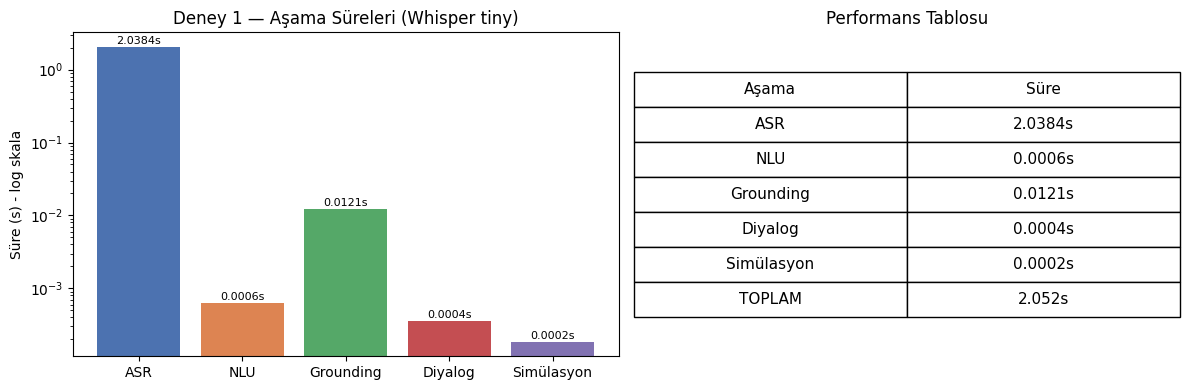

✅ Grafik kaydedildi: deney1_grafik.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV kaydet
df = pd.DataFrame([{
    "model": MODEL_ADI,
    "asr_text": asr_text,
    "asr_confidence": round(asr_confidence, 3),
    "asr_time": round(asr_time, 3),
    "nlu_intent": intent,
    "nlu_entities": str(entities),
    "nlu_confidence": round(nlu_confidence, 3),
    "nlu_time": round(nlu_time, 4),
    "hedef_nesne": str(hedef_nesne),
    "belirsizlik": belirsizlik,
    "grounding_confidence": round(grounding_confidence, 3),
    "grounding_time": round(grounding_time, 4),
    "robot_mesaji": robot_mesaji,
    "eylem_onayli": eylem_onayli,
    "diyalog_time": round(diyalog_time, 4),
    "sim_time": round(sim_time, 4),
    "toplam_sure": round(toplam_sure, 3),
    "eylem_durumu": "Başarılı" if sim_basarili else "İptal/Belirsiz"
}])

df.to_csv("1.Deney_Sonuclari_3.csv", index=False)
print("✅ CSV kaydedildi: deney1_sonuclari.csv")

# Grafik + Tablo
sureler = [asr_time, nlu_time, grounding_time, diyalog_time, sim_time]
etiketler = ["ASR", "NLU", "Grounding", "Diyalog", "Simülasyon"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sol: Grafik (log skala)
axes[0].bar(etiketler, sureler, color=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"])
axes[0].set_yscale("log")
axes[0].set_title(f"Deney 1 — Aşama Süreleri (Whisper {MODEL_ADI})")
axes[0].set_ylabel("Süre (s) - log skala")
for i, v in enumerate(sureler):
    axes[0].text(i, v * 1.1, f"{v:.4f}s", ha="center", fontsize=8)

# Sağ: Tablo
tablo_veri = [[e, f"{v:.4f}s"] for e, v in zip(etiketler, sureler)]
tablo_veri.append(["TOPLAM", f"{toplam_sure:.3f}s"])
tablo = axes[1].table(cellText=tablo_veri, colLabels=["Aşama", "Süre"], loc="center", cellLoc="center")
tablo.auto_set_font_size(False)
tablo.set_fontsize(11)
tablo.scale(1, 2)
axes[1].axis("off")
axes[1].set_title("Performans Tablosu")

plt.tight_layout()
plt.savefig("deney1_grafik.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi: deney1_grafik.png")